In [1]:
import torch, torch.nn as nn
import torch.optim as optim

In [14]:
class LIBS_Backbone(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, kernel_size = 15, stride = 1, padding = 7),    # (batch_size, 16, L)
            nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(16, 32, kernel_size = 9, stride = 1, padding = 4),    # (batch_size, 32, L//4)
            nn.ReLU(), nn.MaxPool1d(4),
            nn.Conv1d(32, 64, kernel_size = 5, stride = 1, padding = 2),    # (batch_size, 64, L//16)
            nn.ReLU(), nn.AdaptiveAvgPool1d(1),     # (batch_size, 64, 1)
        )

    def forward(self, x):
        z = self.conv(x)
        #print(z.shape)  # (batch_size, 64, 1)
        return z.squeeze(-1)    # (batch_size, 64)

class LIBS_SingleHead(nn.Module):
    def __init__(self, n_outputs = 4):
        super().__init__()
        self.backbone = LIBS_Backbone()
        self.head = nn.Sequential(
            nn.Linear(64, 16), nn.ReLU(), nn.Dropout(0.4), nn.Linear(16, n_outputs)
        )

    def forward(self, x):
        z = self.head(self.backbone(x))
        return z    # (batch_size, n_outputs)

In [9]:
model = LIBS_SingleHead(n_outputs=4)

L = 7050
dummy_x = torch.randn(8, 1, L)

out = model(dummy_x)
print(out.shape)   # Should be (8, 4)

torch.Size([8, 4])


In [11]:
print(sum(p.numel() for p in model.parameters()))

16308


In [43]:
# A tiny fake dataset: e.g. 8 examples, fixed, that never changes across steps
X_fake = torch.randn(8, 1, L)
y_fake = torch.randn(8, 4)   # pretend these are the 4 aux targets

model = LIBS_SingleHead(n_outputs=4)
optimizer = optim.Adam(model.parameters(), lr = 1e-3)
loss_fn = nn.MSELoss()

In [44]:
for step in range(10000):
    optimizer.zero_grad()
    pred = model(X_fake)
    loss = loss_fn(pred, y_fake)
    loss.backward()
    optimizer.step()

    if step % 1000 == 0:
        print(f"Step {step}, loss = {loss.item():.4f}")

Step 0, loss = 0.8503
Step 1000, loss = 0.1271
Step 2000, loss = 0.0639
Step 3000, loss = 0.0309
Step 4000, loss = 0.0149
Step 5000, loss = 0.0113
Step 6000, loss = 0.0110
Step 7000, loss = 0.0099
Step 8000, loss = 0.0097
Step 9000, loss = 0.0095


The training loss consistenly drops without the Dropout layer while it might oscillates with it since there is randomness in this layer. With a small sample, we can see nearly perfect fit for the model to the set.

### Real Data!

In [3]:
import sys
import os
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# 确保 src/ 包可被导入
root_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, root_dir)

from config import COAL_TYPES, TRAIN_DIR, TEST_DIR, AUX_COLS, ALPHAS
from src.data   import load_labels, load_coal_spectra
from src.model import get_cv_splits
from src.features import compute_features

In [4]:
label_map, aux_map = load_labels()
coal_type = COAL_TYPES[0]
train_data = load_coal_spectra(TRAIN_DIR, coal_type, label_map, aux_map)
spectra = compute_features(train_data)
aux_labels = train_data['aux']

In [5]:
spectra.shape

(140, 7305)

In [65]:
torch.tensor(spectra, dtype = torch.float32)[0].unsqueeze(0).shape

torch.Size([1, 7305])

In [6]:
from torch.utils.data import Dataset, DataLoader

class LIBSShotDataset(Dataset):
    def __init__(self, spectra, aux_labels):
        """
        spectra: numpy array, shape (n_shots, L)
        aux_labels: numpy array, shape (n_shots, 4) -- already the per-batch label,
                    REPEATED across that batch's shots (same as your Stage 1 Ridge setup)
        """
        self.spectra = torch.tensor(spectra, dtype = torch.float32)    # (n_shots, L))
        self.aux_labels = torch.tensor(aux_labels, dtype = torch.float32)   # (n_shots, 4)

    def __len__(self):
        return self.spectra.shape[0]

    def __getitem__(self, idx):
        # return (spectrum, label) for a single shot
        return self.spectra[idx].unsqueeze(0), self.aux_labels[idx]

In [7]:
groups = train_data['groups']
n_batches = train_data['n_batches']
splits = get_cv_splits(groups, n_batches)

In [103]:
train_idx, val_idx = splits[1]

In [104]:
# Wrap the dataset and build the dataloaders
train_ds = LIBSShotDataset(spectra[train_idx], aux_labels[train_idx])
val_ds = LIBSShotDataset(spectra[val_idx], aux_labels[val_idx])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)  
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False) 

In [105]:
model = LIBS_SingleHead(n_outputs=4)   # dropout back in, as normal
optimizer = optim.Adam(model.parameters(), lr=1e-3) 
loss_fn = nn.MSELoss()
loss_fn_none = nn.MSELoss(reduction='none')

In [106]:
loss_tracker = {'train': [], 'val': [], 'val_mean': []}
for epoch in range(50):
    model.train()
    train_loss = []
    for X, y in train_loader:
        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        train_loss.append(loss.item())

    model.eval()
    val_loss = []
    with torch.no_grad():
        for X, y in val_loader:
            pred = model(X)
            loss = loss_fn_none(pred, y)
            loss = loss.mean(dim = 0)
            val_loss.append(loss)

    mean_trainloss = np.mean(train_loss)
    mean_valloss = np.mean(np.vstack(val_loss), axis = 0)
    loss_tracker['train'].append(mean_trainloss.item())
    loss_tracker['val'].append(mean_valloss)
    loss_tracker['val_mean'].append(mean_valloss.mean().item())

    print(f"Epoch {epoch} | Train loss: {mean_trainloss:.4f} | Val loss: {mean_valloss.mean().item(): .4f}")

Epoch 0 | Train loss: 148.5687 | Val loss:  131.9640
Epoch 1 | Train loss: 149.5950 | Val loss:  131.5172
Epoch 2 | Train loss: 146.6944 | Val loss:  131.0423
Epoch 3 | Train loss: 145.7403 | Val loss:  130.4016
Epoch 4 | Train loss: 145.9377 | Val loss:  129.4937
Epoch 5 | Train loss: 144.3114 | Val loss:  128.2063
Epoch 6 | Train loss: 141.7710 | Val loss:  126.3639
Epoch 7 | Train loss: 138.7536 | Val loss:  123.7165
Epoch 8 | Train loss: 138.7896 | Val loss:  120.0094
Epoch 9 | Train loss: 135.7151 | Val loss:  114.8876
Epoch 10 | Train loss: 125.9715 | Val loss:  107.9419
Epoch 11 | Train loss: 118.2077 | Val loss:  98.7773
Epoch 12 | Train loss: 109.3343 | Val loss:  87.1196
Epoch 13 | Train loss: 94.8372 | Val loss:  72.9072
Epoch 14 | Train loss: 78.2148 | Val loss:  56.7287
Epoch 15 | Train loss: 60.6455 | Val loss:  40.1607
Epoch 16 | Train loss: 41.7674 | Val loss:  26.0650
Epoch 17 | Train loss: 26.9460 | Val loss:  17.4788
Epoch 18 | Train loss: 17.9933 | Val loss:  14.615

In [101]:
import matplotlib.pyplot as plt

def plot_training_trajectories(loss_tracker, aux, val_idx, var_names=None):
    """
    Plots the overall loss trajectory and the % Error (RMSE / True Mean) for 4 aux variables.
    
    Args:
        loss_tracker (dict): Dict containing 'train', 'val', and 'val_mean'.
        aux (np.ndarray or torch.Tensor): Ground truth array of shape (n_batch, 4).
        val_idx (list or np.ndarray): Indices corresponding to the validation set.
        var_names (list): Optional list of 4 strings for variable names.
    """
    if var_names is None:
        var_names = [f"Aux Variable {i+1}" for i in range(4)]
        
    epochs = range(1, len(loss_tracker['train']) + 1)
    
    # ---------------------------------------------------------
    # PLOT 1: Overall Train vs. Val_Mean MSE
    # ---------------------------------------------------------
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, loss_tracker['train'], label='Train MSE', color='tab:blue', lw=2)
    plt.plot(epochs, loss_tracker['val_mean'], label='Validation Mean MSE', color='tab:orange', lw=2)
    plt.title('Overall Model MSE Trajectory', fontsize=14)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('MSE', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # ---------------------------------------------------------
    # PLOT 2: Percentage Error (RMSE / True Mean) for 4 Variables
    # ---------------------------------------------------------
    
    # 1. Convert aux and val_idx to numpy if they are torch tensors
    if isinstance(aux, torch.Tensor):
        aux = aux.detach().cpu().numpy()
    if isinstance(val_idx, torch.Tensor):
        val_idx = val_idx.cpu().numpy()
        
    # 2. Convert validation MSE list of tensors to a single (epochs, 4) numpy array
    # Using stack() then moving to CPU/NumPy to handle device agnosticism 
    val_mse_array = np.vstack(loss_tracker['val'])
    
    # 3. Calculate RMSE for each epoch and variable
    val_rmse_array = np.sqrt(val_mse_array)
    
    # 4. Calculate the true validation mean for the 4 variables
    # We use absolute value of the mean to prevent negative percentages 
    # in case any target variables have a negative domain mean.
    aux_val = aux[val_idx]
    true_val_means = np.abs(aux_val.mean(axis=0)) 
    
    # 5. Calculate Percentage Error (% RMSE)
    # Shape: (epochs, 4)
    pct_error = (val_rmse_array / true_val_means) * 100
    
    # 6. Plot in a 2x2 grid
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for i in range(4):
        ax = axes[i]
        ax.plot(epochs, pct_error[:, i], color='tab:red', lw=2)
        ax.set_title(f'{var_names[i]} Error (% RMSE)', fontsize=12, fontweight='bold')
        ax.set_xlabel('Epochs')
        ax.set_ylabel('% Error (RMSE / Val Mean)')
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Annotate the final error rate on the plot for quick reading
        final_err = pct_error[-1, i]
        ax.axhline(y=final_err, color='gray', linestyle=':', alpha=0.8)
        
        # Smart positioning for the text annotation
        y_limits = ax.get_ylim()
        y_range = y_limits[1] - y_limits[0]
        ax.text(
            epochs[-1] * 0.85, 
            final_err + (y_range * 0.05), 
            f"Final: {final_err:.2f}%", 
            color='dimgray', 
            fontweight='bold'
        )
        
    plt.suptitle('Validation Percentage Error Trajectories per Auxiliary Variable', fontsize=16)
    plt.tight_layout()
    plt.show()


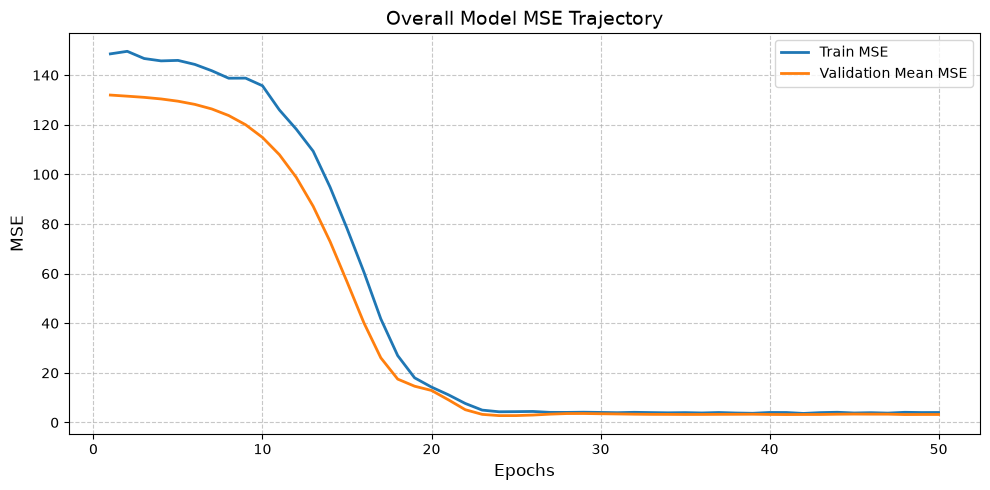

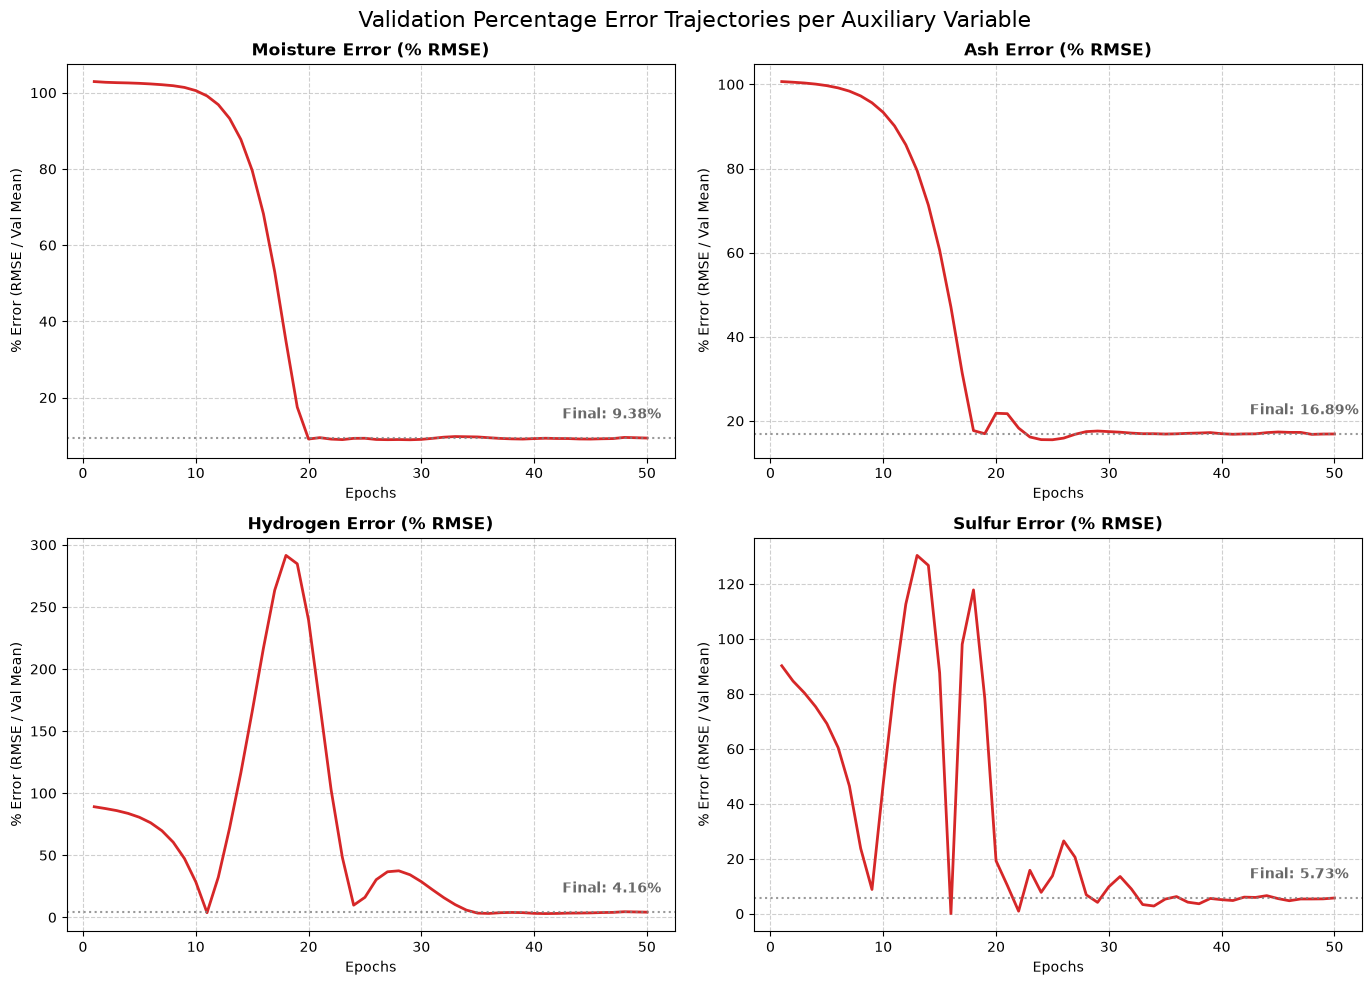

In [107]:
# --- Example Usage ---
plot_training_trajectories(
    loss_tracker=loss_tracker, 
    aux=aux_labels, 
    val_idx=val_idx,
    var_names=["Moisture", "Ash", "Hydrogen", "Sulfur"]
)

In [109]:
model = LIBS_SingleHead(n_outputs=4)   # dropout back in, as normal
optimizer = optim.Adam(model.parameters(), lr=1e-3) 
loss_fn = nn.MSELoss()

loss_tracker = {'train': [], 'val': []}
best_val = float('inf')
best_epoch = None
best_model_state = None

for epoch in range(50):
    model.train()
    train_loss = []
    for X, y in train_loader:
        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        train_loss.append(loss.item())

    model.eval()
    val_loss = []
    with torch.no_grad():
        for X, y in val_loader:
            pred = model(X)
            loss = loss_fn(pred, y)
            val_loss.append(loss.item())

    mean_trainloss = np.mean(train_loss)
    mean_valloss = np.mean(val_loss)
    loss_tracker['train'].append(mean_trainloss.item())
    loss_tracker['val'].append(mean_valloss.item())

    # Get the best model based on val loss
    if mean_valloss < best_val:
        best_val = mean_valloss
        best_epoch = epoch
        best_model_state = model.state_dict()

    print(f"Epoch {epoch} | Train loss: {mean_trainloss:.4f} | Val loss: {mean_valloss: .4f}")

print(f"Best model found at epoch {best_epoch} with validation loss: {best_val: .4f}")

Epoch 0 | Train loss: 146.2032 | Val loss:  127.5900
Epoch 1 | Train loss: 142.0641 | Val loss:  126.8511
Epoch 2 | Train loss: 142.6444 | Val loss:  125.8104
Epoch 3 | Train loss: 140.6135 | Val loss:  124.2052
Epoch 4 | Train loss: 139.9422 | Val loss:  121.6936
Epoch 5 | Train loss: 135.0505 | Val loss:  117.8665
Epoch 6 | Train loss: 132.0202 | Val loss:  112.1383
Epoch 7 | Train loss: 126.1985 | Val loss:  103.8115
Epoch 8 | Train loss: 114.1258 | Val loss:  92.1484
Epoch 9 | Train loss: 101.5198 | Val loss:  76.6160
Epoch 10 | Train loss: 83.8734 | Val loss:  57.5438
Epoch 11 | Train loss: 61.6458 | Val loss:  37.0936
Epoch 12 | Train loss: 40.3660 | Val loss:  20.6393
Epoch 13 | Train loss: 24.0077 | Val loss:  15.0994
Epoch 14 | Train loss: 20.4016 | Val loss:  17.7720
Epoch 15 | Train loss: 20.0506 | Val loss:  15.7913
Epoch 16 | Train loss: 15.8334 | Val loss:  10.0164
Epoch 17 | Train loss: 11.0421 | Val loss:  6.2756
Epoch 18 | Train loss: 8.7711 | Val loss:  5.0123
Epoch 1

## On the full data set!

In [110]:
pred_model = LIBS_SingleHead(n_outputs=4)
model.load_state_dict(best_model_state)

<All keys matched successfully>

In [114]:
model.eval()
with torch.no_grad():
    prediction = model(val_ds.spectra.unsqueeze(1))

In [ ]:
prediction.numpy().shape  # Should be (n_val_samples, 4)

(26, 4)

In [15]:
torch.manual_seed(40)
oof_pred = np.zeros_like(aux_labels)
for i, (train_idx, val_idx) in enumerate(splits):
    print(f"Training fold {i+1}...")
    print("="*30)

    # Wrap the dataset and build the dataloaders
    train_ds = LIBSShotDataset(spectra[train_idx], aux_labels[train_idx])
    val_ds = LIBSShotDataset(spectra[val_idx], aux_labels[val_idx])

    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)  
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False) 

    model = LIBS_SingleHead(n_outputs=4)   # dropout back in, as normal
    optimizer = optim.Adam(model.parameters(), lr=1e-3) 
    loss_fn = nn.MSELoss()

    best_val = float('inf')
    best_epoch = None
    best_model_state = None

    for epoch in range(50):
        model.train()
        train_loss = []
        for X, y in train_loader:
            optimizer.zero_grad()
            pred = model(X)
            loss = loss_fn(pred, y)
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())

        model.eval()
        val_loss = []
        with torch.no_grad():
            for X, y in val_loader:
                pred = model(X)
                loss = loss_fn(pred, y)
                val_loss.append(loss.item())

        mean_trainloss = np.mean(train_loss)
        mean_valloss = np.mean(val_loss)

        # Get the best model based on val loss
        if mean_valloss < best_val:
            best_val = mean_valloss
            best_epoch = epoch
            best_model_state = model.state_dict()

        print(f"Epoch {epoch} | Train loss: {mean_trainloss:.4f} | Val loss: {mean_valloss: .4f}")

    print('-' * 30)
    print(f"Best model found at epoch {best_epoch} with validation loss: {best_val: .4f}")

    pred_model = LIBS_SingleHead(n_outputs=4)
    pred_model.load_state_dict(best_model_state)
    pred_model.eval()
    with torch.no_grad():
        oof_pred[val_idx] = pred_model(val_ds.spectra.unsqueeze(1))

Training fold 1...
Epoch 0 | Train loss: 155.8675 | Val loss:  101.2219
Epoch 1 | Train loss: 153.4992 | Val loss:  100.9621
Epoch 2 | Train loss: 155.8306 | Val loss:  100.6403
Epoch 3 | Train loss: 154.2856 | Val loss:  100.1461
Epoch 4 | Train loss: 154.2551 | Val loss:  99.3488
Epoch 5 | Train loss: 152.6705 | Val loss:  98.0059
Epoch 6 | Train loss: 150.6798 | Val loss:  95.8596
Epoch 7 | Train loss: 149.4856 | Val loss:  92.5532
Epoch 8 | Train loss: 142.9075 | Val loss:  87.6214
Epoch 9 | Train loss: 135.9547 | Val loss:  80.5707
Epoch 10 | Train loss: 125.5335 | Val loss:  71.0794
Epoch 11 | Train loss: 116.1601 | Val loss:  59.1207
Epoch 12 | Train loss: 95.9636 | Val loss:  45.0235
Epoch 13 | Train loss: 76.7487 | Val loss:  30.1288
Epoch 14 | Train loss: 71.2764 | Val loss:  16.7711
Epoch 15 | Train loss: 66.2704 | Val loss:  7.7754
Epoch 16 | Train loss: 59.8625 | Val loss:  3.6352
Epoch 17 | Train loss: 50.5440 | Val loss:  1.6722
Epoch 18 | Train loss: 52.7878 | Val loss:

In [16]:
torch.manual_seed(40)
train_idx, val_idx = splits[-1]

print(f"Training fold {5}...")
print("="*30)

# Wrap the dataset and build the dataloaders
train_ds = LIBSShotDataset(spectra[train_idx], aux_labels[train_idx])
val_ds = LIBSShotDataset(spectra[val_idx], aux_labels[val_idx])

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)  
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False) 

model = LIBS_SingleHead(n_outputs=4)   # dropout back in, as normal
optimizer = optim.Adam(model.parameters(), lr=1e-3) 
loss_fn = nn.MSELoss()

best_val = float('inf')
best_epoch = None
best_model_state = None

for epoch in range(100):
    model.train()
    train_loss = []
    for X, y in train_loader:
        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        train_loss.append(loss.item())

    model.eval()
    val_loss = []
    with torch.no_grad():
        for X, y in val_loader:
            pred = model(X)
            loss = loss_fn(pred, y)
            val_loss.append(loss.item())

    mean_trainloss = np.mean(train_loss)
    mean_valloss = np.mean(val_loss)

    # Get the best model based on val loss
    if mean_valloss < best_val:
        best_val = mean_valloss
        best_epoch = epoch
        best_model_state = model.state_dict()

    print(f"Epoch {epoch} | Train loss: {mean_trainloss:.4f} | Val loss: {mean_valloss: .4f}")

print('-' * 30)
print(f"Best model found at epoch {best_epoch} with validation loss: {best_val: .4f}")

# pred_model = LIBS_SingleHead(n_outputs=4)
# pred_model.load_state_dict(best_model_state)
# pred_model.eval()
# with torch.no_grad():
#     oof_pred[val_idx] = pred_model(val_ds.spectra.unsqueeze(1))

Training fold 5...
Epoch 0 | Train loss: 132.1522 | Val loss:  207.6329
Epoch 1 | Train loss: 131.8750 | Val loss:  207.2681
Epoch 2 | Train loss: 129.9314 | Val loss:  206.8035
Epoch 3 | Train loss: 130.0127 | Val loss:  206.1310
Epoch 4 | Train loss: 130.0551 | Val loss:  205.0187
Epoch 5 | Train loss: 128.4678 | Val loss:  203.1552
Epoch 6 | Train loss: 126.1293 | Val loss:  200.2250
Epoch 7 | Train loss: 124.3281 | Val loss:  195.6702
Epoch 8 | Train loss: 119.2919 | Val loss:  188.8795
Epoch 9 | Train loss: 111.8118 | Val loss:  179.0689
Epoch 10 | Train loss: 108.6099 | Val loss:  165.6006
Epoch 11 | Train loss: 96.3768 | Val loss:  147.8236
Epoch 12 | Train loss: 80.2814 | Val loss:  125.5140
Epoch 13 | Train loss: 68.9434 | Val loss:  99.8722
Epoch 14 | Train loss: 60.0537 | Val loss:  73.7548
Epoch 15 | Train loss: 50.9249 | Val loss:  51.7692
Epoch 16 | Train loss: 46.8235 | Val loss:  38.7396
Epoch 17 | Train loss: 41.3636 | Val loss:  37.1410
Epoch 18 | Train loss: 44.1340 

No improvement for the last fold from adding more epoches.

In [19]:
mse = (oof_pred - aux_labels)**2
rmse = np.sqrt(np.mean(mse, axis = 0))
true_mean = np.mean(aux_labels, axis = 0)
for i, aux in enumerate(AUX_COLS):
    print(f"Aux variable: {aux} | RMSE: {rmse[i]: .4f} | Percentage error: {rmse[i] / true_mean[i] * 100: .2f}")

Aux variable: 全水分 | RMSE:  1.8173 | Percentage error:  19.54
Aux variable: 灰分 | RMSE:  4.9093 | Percentage error:  22.53
Aux variable: 氢 | RMSE:  0.2054 | Percentage error:  9.03
Aux variable: 硫 | RMSE:  0.0717 | Percentage error:  16.34


Awful results!!